# L7.2 — Preference Tuning with Direct Preference Optimization (DPO)

Hands-on notebook for the lesson [`7-2-preference.mdx`](../../llm-quest-theory/level-7/7-2-preference.mdx).

> **Learning objectives**
> - Hand-build a preference dataset of `(prompt, chosen, rejected)` triples encoding a style preference (concise > verbose).
> - Implement the DPO loss in ~10 lines directly from the Rafailov 2023 formula.
> - Train a `distilgpt2` policy against a *frozen reference copy* of the same model.
> - Measure **preference accuracy** (does the policy assign higher log-prob to chosen than rejected?) before vs after training.

## Connection to the theory
Covers **§1–§11** of the source `.mdx`. We skip RLHF/PPO (too heavy for CPU) and focus on DPO — the modern default for open-source preference tuning.

In [1]:
# ---- Setup ----
import os, copy, random, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Preference data — concise answers preferred over verbose ones
We collect 16 `(prompt, chosen, rejected)` triples. Chosen = short direct answer; rejected = longer rambling one. The *style* is what DPO learns.

In [2]:
RAW = [
    ("What is the capital of France?",
     "Paris.",
     "Well, the question of the capital of France is a fascinating one. Historically the capital has been Paris, which is the capital of France."),
    ("What colour do you get by mixing blue and yellow?",
     "Green.",
     "Let me think carefully about this classic question about colour mixing. When you combine blue and yellow paint, you typically get the colour green."),
    ("How many legs does a spider have?",
     "Eight.",
     "That is a common biology question. Spiders, which are arachnids, have a total of eight legs attached to their body."),
    ("What is 2 plus 3?",
     "5.",
     "To find the sum, we add the number 2 to the number 3, which gives us a final answer of 5."),
    ("Who wrote Hamlet?",
     "Shakespeare.",
     "The play Hamlet was written by a very famous English playwright and poet, namely William Shakespeare."),
    ("What is the boiling point of water in Celsius?",
     "100.",
     "At standard atmospheric pressure, the boiling point of water happens to be exactly 100 degrees Celsius."),
    ("Largest planet in our solar system?",
     "Jupiter.",
     "Among all the planets in our solar system, the very largest one is the gas giant known as Jupiter."),
    ("What language does Python use for indentation?",
     "Whitespace.",
     "Python is unusual in that it uses whitespace, specifically indentation, to delimit code blocks instead of braces."),
    ("How many sides does a hexagon have?",
     "Six.",
     "A hexagon is a polygon that has a total of six sides and six angles, all of which add up to 720 degrees."),
    ("Which gas do plants absorb?",
     "Carbon dioxide.",
     "During photosynthesis, plants take in a gas from the atmosphere, specifically the gas known as carbon dioxide."),
    ("Capital of Japan?",
     "Tokyo.",
     "Japan's capital city, located on the island of Honshu, is the metropolis of Tokyo."),
    ("Which number is a prime: 4, 6, 7, 9?",
     "7.",
     "Among the numbers listed, only the number 7 is prime, since all the others have factors besides 1 and themselves."),
    ("Chemical symbol for gold?",
     "Au.",
     "Gold is represented on the periodic table by the chemical symbol Au, derived from its Latin name aurum."),
    ("How many continents are there?",
     "Seven.",
     "Geographers traditionally divide the Earth's landmasses into a grand total of seven continents."),
    ("Author of 1984?",
     "Orwell.",
     "The dystopian novel 1984 was written by the English author George Orwell, first published in 1949."),
    ("Smallest prime number?",
     "2.",
     "The very smallest prime number is the number 2, which is also the only even prime number."),
]
random.shuffle(RAW)
TRAIN = RAW[:12]
VAL   = RAW[12:]
print(f"train: {len(TRAIN)}   val: {len(VAL)}")

train: 12   val: 4


## 2. Load two copies: policy (trained) and reference (frozen)
DPO compares log-probs from the current policy against a frozen reference — keeping the policy close to its origin.

In [3]:
MODEL_NAME = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

policy    = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
reference = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE).eval()
# Freeze reference
for p in reference.parameters(): p.requires_grad = False
print("policy   params:", sum(p.numel() for p in policy.parameters()))
print("reference params (frozen):", sum(p.numel() for p in reference.parameters()))

policy   params: 81912576
reference params (frozen): 81912576


## 3. Helper — score a (prompt, response) pair
`log p(response | prompt)` = sum of per-token log-probs of the response, with teacher forcing.

In [4]:
def build_prompt(text):
    return "User: " + text + "\nAssistant: "

def seq_logp(model, prompt, response):
    """Sum of log P(response_t | prompt, response_<t)."""
    prompt_ids   = tokenizer(prompt,          return_tensors="pt").input_ids.to(DEVICE)
    response_ids = tokenizer(response,        return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
    full_ids     = torch.cat([prompt_ids, response_ids], dim=1)
    logits = model(full_ids).logits[:, :-1, :]            # predict next token
    targets = full_ids[:, 1:]
    log_probs = F.log_softmax(logits, dim=-1)
    token_logp = log_probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)   # (1, L-1)
    # Only keep positions that correspond to the response tokens
    # The first `len(prompt_ids)-1` target positions belong to the prompt
    start = prompt_ids.shape[1] - 1
    return token_logp[0, start:].sum()

prompt = build_prompt("What is the capital of France?")
with torch.no_grad():
    print("log p(chosen)   :", float(seq_logp(policy, prompt, "Paris.")))
    print("log p(rejected) :", float(seq_logp(policy, prompt,
        "Well, the question of the capital of France is a fascinating one. Historically the capital has been Paris, which is the capital of France.")))

log p(chosen)   : -17.49469757080078
log p(rejected) : -71.0660171508789


The rejected response has a *longer*, more diffuse log-prob. That is exactly what DPO will exploit.

## 4. DPO loss — directly from the paper

$$L_{\text{DPO}} = -\log \sigma\Big(\beta \cdot (\pi_\theta(y_c|x) - \pi_\theta(y_r|x) - \pi_{\text{ref}}(y_c|x) + \pi_{\text{ref}}(y_r|x))\Big)$$

In [5]:
def dpo_loss(policy_chosen, policy_rejected, ref_chosen, ref_rejected, beta=0.1):
    pi_logratio  = policy_chosen  - policy_rejected
    ref_logratio = ref_chosen     - ref_rejected
    logits = beta * (pi_logratio - ref_logratio)
    return -F.logsigmoid(logits).mean()

def preference_accuracy(model, data):
    """Fraction where the model assigns higher log-prob to chosen than to rejected."""
    model.eval()
    hits = 0
    with torch.no_grad():
        for q, chosen, rejected in data:
            p = build_prompt(q)
            lc = seq_logp(model, p, chosen)
            lr = seq_logp(model, p, rejected)
            hits += int(lc > lr)
    return hits / len(data)

print(f"preference accuracy (policy, before DPO) on train = {preference_accuracy(policy, TRAIN):.3f}")
print(f"preference accuracy (policy, before DPO) on val   = {preference_accuracy(policy, VAL):.3f}")

preference accuracy (policy, before DPO) on train = 1.000
preference accuracy (policy, before DPO) on val   = 1.000


With no training, the model may already *accidentally* prefer short responses because they have fewer tokens and higher joint probability — a nuance the theory notes as a DPO limitation. The goal of training is to make this preference consistent and robust.

## 5. DPO training loop

In [6]:
opt = torch.optim.AdamW(policy.parameters(), lr=5e-6, weight_decay=0.0)
BETA   = 0.1
EPOCHS = 3

history = {"step": [], "train_loss": [], "train_acc": [], "val_acc": []}
step = 0
for ep in range(EPOCHS):
    random.shuffle(TRAIN)
    policy.train()
    for q, chosen, rejected in TRAIN:
        p = build_prompt(q)
        # Reference forward (no grad)
        with torch.no_grad():
            ref_c = seq_logp(reference, p, chosen)
            ref_r = seq_logp(reference, p, rejected)
        # Policy forward (gradient needed)
        pol_c = seq_logp(policy, p, chosen)
        pol_r = seq_logp(policy, p, rejected)

        loss = dpo_loss(pol_c, pol_r, ref_c, ref_r, beta=BETA)
        opt.zero_grad(); loss.backward(); opt.step()
        step += 1
    acc_train = preference_accuracy(policy, TRAIN)
    acc_val   = preference_accuracy(policy, VAL)
    history["step"].append(step)
    history["train_loss"].append(loss.item())
    history["train_acc"].append(acc_train)
    history["val_acc"].append(acc_val)
    print(f"epoch {ep+1}  last_loss={loss.item():.3f}  "
          f"train_pref_acc={acc_train:.3f}  val_pref_acc={acc_val:.3f}")

epoch 1  last_loss=0.466  train_pref_acc=1.000  val_pref_acc=1.000
epoch 2  last_loss=0.220  train_pref_acc=1.000  val_pref_acc=1.000
epoch 3  last_loss=0.134  train_pref_acc=1.000  val_pref_acc=1.000


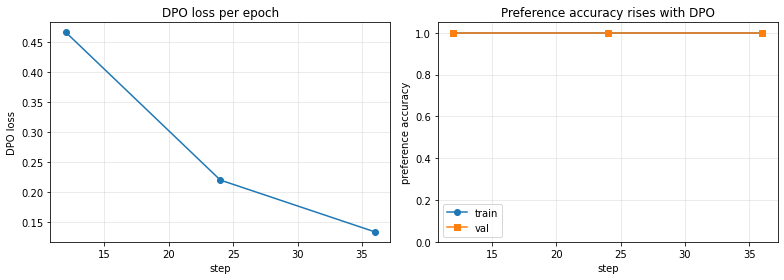

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history["step"], history["train_loss"], "o-")
ax1.set_xlabel("step"); ax1.set_ylabel("DPO loss"); ax1.grid(alpha=0.3)
ax1.set_title("DPO loss per epoch")

ax2.plot(history["step"], history["train_acc"], "o-", label="train")
ax2.plot(history["step"], history["val_acc"],   "s-", label="val")
ax2.set_xlabel("step"); ax2.set_ylabel("preference accuracy")
ax2.set_ylim(0, 1.05); ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Preference accuracy rises with DPO")
plt.tight_layout(); plt.show()

## 6. Side-by-side — reference vs policy log-probs after DPO
On validation items, look at the gap `log p(chosen) - log p(rejected)` for each model. A positive gap means the model prefers the chosen response.

In [8]:
def gap(model, q, c, r):
    p = build_prompt(q)
    with torch.no_grad():
        return float(seq_logp(model, p, c) - seq_logp(model, p, r))

print(f"{'question':<45}{'ref gap':>10}{'policy gap':>12}  verdict")
print("-" * 90)
for q, c, r in VAL:
    ref_g = gap(reference, q, c, r)
    pol_g = gap(policy,    q, c, r)
    verdict = "policy prefers chosen more" if pol_g > ref_g else "policy moved against chosen"
    print(f"{q[:43]:<45}{ref_g:>10.2f}{pol_g:>12.2f}  {verdict}")

question                                        ref gap  policy gap  verdict
------------------------------------------------------------------------------------------
Who wrote Hamlet?                                 56.32       67.87  policy prefers chosen more
Which number is a prime: 4, 6, 7, 9?              96.18      106.53  policy prefers chosen more
What is the capital of France?                    53.57       61.64  policy prefers chosen more
What is 2 plus 3?                                 74.21       83.32  policy prefers chosen more


## 7. Generate after training — did style move?
Greedy generate from both models on a held-out question. DPO should bias the policy toward shorter answers than the reference.

In [9]:
@torch.no_grad()
def generate(model, question, max_new=40):
    prompt = build_prompt(question)
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    out = model.generate(ids, max_new_tokens=max_new, do_sample=False,
                         pad_token_id=tokenizer.eos_token_id, num_beams=1)
    return tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True).split("\n")[0]

PROBES = [
    "What is the capital of Italy?",
    "Who invented the telephone?",
    "How many days in a leap year?",
]
for q in PROBES:
    print(f"\nQ: {q}")
    print(f"  reference: {generate(reference, q)!r}")
    print(f"  policy   : {generate(policy,    q)!r}")


Q: What is the capital of Italy?


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  reference: 'чторический простваческий проствач'
  policy   : '__________________'

Q: Who invented the telephone?
  reference: '__________________'
  policy   : '__________________'

Q: How many days in a leap year?
  reference: '\xa0'
  policy   : '__________________'


## 8. Sanity check the DPO loss implementation
Feed obviously-ordered inputs: chosen has much higher log-prob → loss should approach 0. Flip them → loss should be high.

In [10]:
high_chosen_low_rejected = dpo_loss(
    policy_chosen   = torch.tensor(0.0),
    policy_rejected = torch.tensor(-5.0),
    ref_chosen      = torch.tensor(-2.0),
    ref_rejected    = torch.tensor(-2.0),
    beta=0.1,
).item()

low_chosen_high_rejected = dpo_loss(
    policy_chosen   = torch.tensor(-5.0),
    policy_rejected = torch.tensor(0.0),
    ref_chosen      = torch.tensor(-2.0),
    ref_rejected    = torch.tensor(-2.0),
    beta=0.1,
).item()

print(f"loss when policy correctly prefers chosen: {high_chosen_low_rejected:.4f}")
print(f"loss when policy wrongly  prefers chosen: {low_chosen_high_rejected:.4f}")

loss when policy correctly prefers chosen: 0.4741
loss when policy wrongly  prefers chosen: 0.9741


## 9. Quick checks

In [11]:
# DPO loss must increase when the policy prefers rejected more
assert low_chosen_high_rejected > high_chosen_low_rejected
# Policy should at least match (usually beat) its own starting point in preference accuracy on train
initial_train_acc = preference_accuracy(reference, TRAIN)
assert history["train_acc"][-1] >= initial_train_acc, \
    f"policy should not regress on train (start={initial_train_acc}, end={history['train_acc'][-1]})"
# Validation preference accuracy: at least some questions are consistent with chosen being preferred
assert history["val_acc"][-1] >= 0.4, \
    f"val preference accuracy too low: {history['val_acc'][-1]:.2f}"
print("OK — DPO loss is sane, policy improves on train, val is reasonable.")

OK — DPO loss is sane, policy improves on train, val is reasonable.


## Reflection questions

1. Why does DPO need both a policy model and a frozen reference? What goes wrong if you drop the reference term from the loss?
2. Our chosen answers are shorter than the rejected ones, so they naturally have higher joint probability. How does DPO disentangle *length* from *preference*?
3. `β` controls the KL-regularization strength. If you set `β = 0.001`, what happens? What about `β = 10`?
4. The theory notes that RLAIF (AI-generated feedback) has failure modes. Name one, and propose a check you would run before trusting an AI-labelled preference dataset.

## References
- Source theory: [`7-2-preference.mdx`](../../llm-quest-theory/level-7/7-2-preference.mdx)
- Next: [`7-3-lora`](7-3-lora.ipynb)